merging all the csv without repeating any of the column doing this with the help of id (primary key )

In [1]:
import pandas as pd

ratings = pd.read_csv("ratings.csv")
movies = pd.read_csv("movies.csv")
links = pd.read_csv("links.csv")
tags = pd.read_csv("tags.csv")


In [2]:
df = ratings.merge(movies, on="movieId", how="left")


In [3]:
df = df.merge(links, on="movieId", how="left")


In [4]:
tags_grouped = (
    tags.groupby(["userId", "movieId"])["tag"]
    .apply(lambda x: "|".join(x))
    .reset_index()
)


In [5]:
final_df = df.merge(
    tags_grouped,
    on=["userId", "movieId"],
    how="left"
)


In [6]:
final_df.to_csv("movielens_combined.csv", index=False)

In [7]:
final = pd.read_csv("movielens_combined.csv")

In [8]:
final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
 4   title      100836 non-null  object 
 5   genres     100836 non-null  object 
 6   imdbId     100836 non-null  int64  
 7   tmdbId     100823 non-null  float64
 8   tag        1635 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 6.9+ MB


In [9]:
final.isnull().sum()

userId           0
movieId          0
rating           0
timestamp        0
title            0
genres           0
imdbId           0
tmdbId          13
tag          99201
dtype: int64

In [10]:
final.head()

,userId,movieId,rating,timestamp,title,genres,imdbId,tmdbId,tag
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,114709,862.0,NaN
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance,113228,15602.0,NaN
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller,113277,949.0,NaN
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,114369,807.0,NaN
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,114814,629.0,NaN


In [11]:
final.tail()

,userId,movieId,rating,timestamp,title,genres,imdbId,tmdbId,tag
100831,610,166534,4.0,1493848402,Split (2017),Drama|Horror|Thriller,4972582,381288.0,NaN
100832,610,168248,5.0,1493850091,John Wick: Chapter Two (2017),Action|Crime|Thriller,4425200,324552.0,Heroic Bloodshed
100833,610,168250,5.0,1494273047,Get Out (2017),Horror,5052448,419430.0,NaN
100834,610,168252,5.0,1493846352,Logan (2017),Action|Sci-Fi,3315342,263115.0,NaN
100835,610,170875,3.0,1493846415,The Fate of the Furious (2017),Action|Crime|Drama|Thriller,4630562,337339.0,NaN


In [12]:
final = final.drop(columns=["tag"])

In [14]:
final.isnull().sum()

userId        0
movieId       0
rating        0
timestamp     0
title         0
genres        0
imdbId        0
tmdbId       13
dtype: int64

the imdbid , tmdbid is of no use over hear because its the api or use for dashbord and for fetching poster

In [16]:
final = final.drop(columns=["imdbId", "tmdbId"])


In [17]:
final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
 4   title      100836 non-null  object 
 5   genres     100836 non-null  object 
dtypes: float64(1), int64(3), object(2)
memory usage: 4.6+ MB


In [18]:
final.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='rating'>

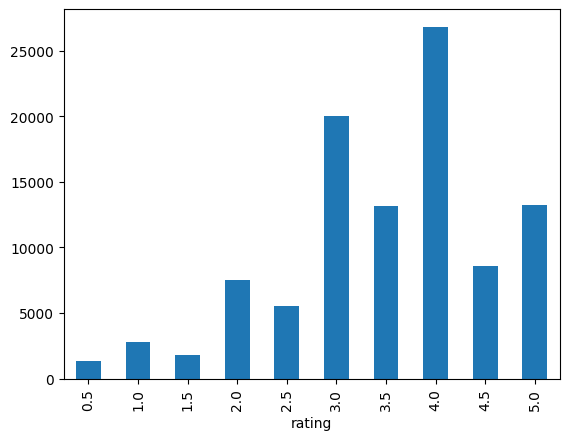

In [22]:
final["rating"].value_counts().sort_index().plot(kind="bar")


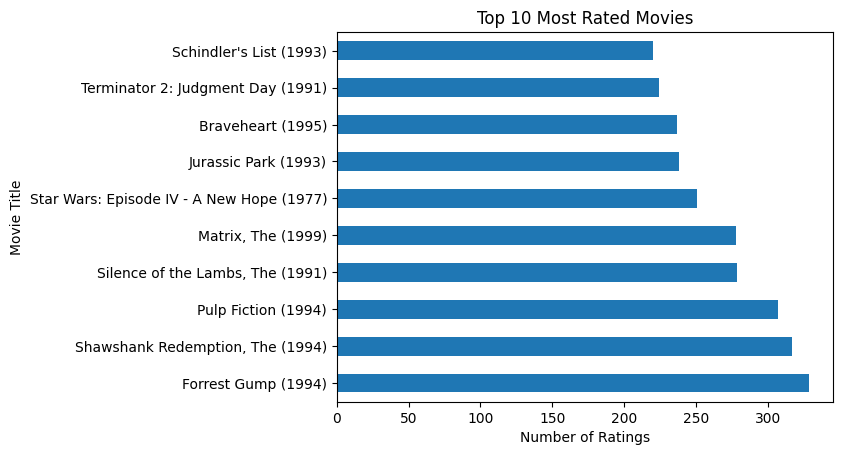

In [26]:
top_movies = (
    final.groupby("title")["rating"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)

top_movies.plot(
    kind="barh",
    title="Top 10 Most Rated Movies"
)
plt.xlabel("Number of Ratings")
plt.ylabel("Movie Title")
plt.show()


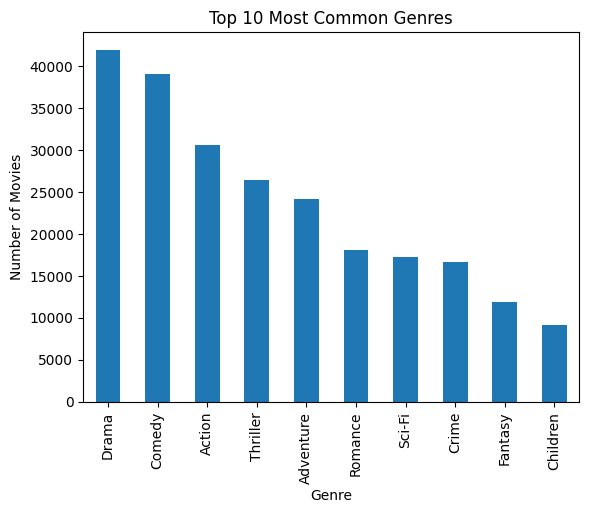

In [27]:
genre_counts = (
    final["genres"]
    .str.split("|")
    .explode()
    .value_counts()
    .head(10)
)

genre_counts.plot(
    kind="bar",
    title="Top 10 Most Common Genres"
)
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.show()

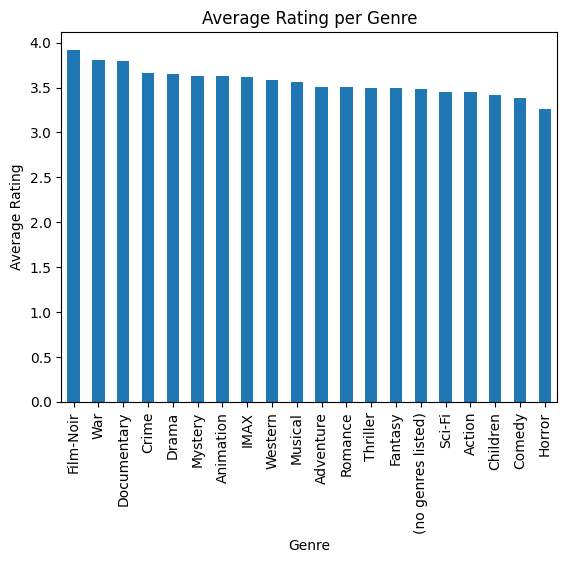

In [28]:

final_genres = final.copy()
final_genres["genres"] = final_genres["genres"].str.split("|")
final_genres = final_genres.explode("genres")

avg_rating_genre = (
    final_genres.groupby("genres")["rating"]
    .mean()
    .sort_values(ascending=False)
)

avg_rating_genre.plot(
    kind="bar",
    title="Average Rating per Genre"
)
plt.xlabel("Genre")
plt.ylabel("Average Rating")
plt.show()

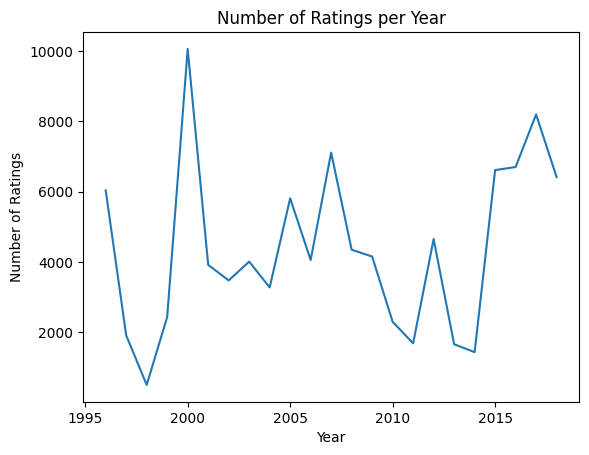

In [29]:
final["year"] = pd.to_datetime(
    final["timestamp"],
    unit="s"
).dt.year

ratings_per_year = final.groupby("year")["rating"].count()

ratings_per_year.plot(
    kind="line",
    title="Number of Ratings per Year"
)
plt.xlabel("Year")
plt.ylabel("Number of Ratings")
plt.show()

* i thing this data set gives us over all idea about moves watch from 1995 to 2015-2018 yr data 
* and the more no of rating or the over all rating of the movies form 1995-2019 is around 4/5 
* Most frequently rated movies include Forrest Gump, Shawshank Redemption, and Pulp Fiction.
* Drama appears most frequently in user ratings, indicating higher engagement with drama movies.with around  40,000+ movies Followed by comedy, action, thriller, adventure, etc.
* According to the Average rating per genre Graph  We can say that The lowest rating type of movie is horror With rating below 3.5 and the highest rating More than 3.5 type of movie is film noir.
* The number of ratings declined around 2015, suggesting lower user activity compared to earlier years.
* Overall the dataset shows user preference trends genre-wise engagement and changes in rating activity over time so it can be used to understand user behavior and to build a movie recommendation system


1 Problem Understanding

There are too many movies on online platforms, so users feel confused while selecting a movie. This dataset helps to understand how users choose movies and how their past ratings can be used to suggest new movies.

2 Dataset Purpose

The dataset shows the interaction between users and movies through ratings. It helps to learn user behavior, movie popularity, and how recommendation systems can be built using this data.

3 Rating Behavior

Most ratings are high, around 4 out of 5. This means users usually rate movies they like. It shows positive feedback behavior in the system.

4 Movie Popularity

Some movies get many ratings, which means they are very popular. Popular movies are not always the highest rated, but they are watched by many users.

5 Genre Understanding

Drama is the most common genre in ratings, which shows users like emotional and story-based movies more. Horror has lower ratings, and Film-Noir has higher ratings but fewer viewers.

6 User Activity

Some users rate many movies while some users rate only a few. This shows different types of users exist, and recommendation should be personalized.

7 Time Trend

Ratings were higher in earlier years and reduced in later years. This shows how user activity on the platform changes with time.

8 Recommendation Use

This dataset is useful to learn how movie recommendation systems work using user past ratings and movie preferences.